In [1]:
import os
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Path to the main folder containing subfolders for each object
main_data_path = 'D:\\Retina dataset for paper\\Bucket measurements dataset'  # Update this with the correct main folder path
data_dict = {}

# Loop through each subfolder (one for each object class)
for folder_name in os.listdir(main_data_path):
    folder_path = os.path.join(main_data_path, folder_name)
    
    # Check if the folder path is a directory
    if os.path.isdir(folder_path):
        object_data_list = []  # List to store data for each file within the folder
        
        # Loop through each MATLAB file in the subfolder
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.mat'):
                file_path = os.path.join(folder_path, file_name)
                
                # Open the MATLAB file and load the 'measurements' data
                with h5py.File(file_path, 'r') as f:
                    data = np.array(f['measurements'])  # Load 'measurements' dataset
                    object_data_list.append(data)
                    print(f"Loaded {file_name} from {folder_name} with shape: {data.shape}")
        # Store the list of loaded data arrays for this object class
        data_dict[folder_name] = object_data_list

# Dictionary to hold processed data and labels
processed_data = []
labels = []

# Define labels for each class
class_labels = {
    'cataract': 0,
    'diabetic_retinopathy': 1,
    'glaucoma': 2,
    'normal': 3,

}

# Preprocess data for each class
for object_name, data_list in data_dict.items():
    for data in data_list:
        # Reshape data from (1, 3274000) to (num_samples, 3274)
        reshaped_data = data.reshape(-1, 3274)  # Reshaping according to the data size
        
        # Normalize
        scaler = StandardScaler()
        normalized_data = scaler.fit_transform(reshaped_data)
        
        # Append to the processed data
        processed_data.append(normalized_data)
        labels.extend([class_labels[object_name]] * normalized_data.shape[0])  # Assign label per object

# Convert to NumPy arrays
processed_data = np.concatenate(processed_data, axis=0)
labels = np.array(labels)

# Split into training, validation, and test sets (e.g., 70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(processed_data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
# Data is now ready for model input
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Loaded cataract (1).mat from cataract with shape: (1, 3274000)
Loaded cataract (10).mat from cataract with shape: (1, 3274000)
Loaded cataract (11).mat from cataract with shape: (1, 3274000)
Loaded cataract (12).mat from cataract with shape: (1, 3274000)
Loaded cataract (13).mat from cataract with shape: (1, 3274000)
Loaded cataract (14).mat from cataract with shape: (1, 3274000)
Loaded cataract (15).mat from cataract with shape: (1, 3274000)
Loaded cataract (16).mat from cataract with shape: (1, 3274000)
Loaded cataract (17).mat from cataract with shape: (1, 3274000)
Loaded cataract (18).mat from cataract with shape: (1, 3274000)
Loaded cataract (19).mat from cataract with shape: (1, 3274000)
Loaded cataract (2).mat from cataract with shape: (1, 3274000)
Loaded cataract (20).mat from cataract with shape: (1, 3274000)
Loaded cataract (21).mat from cataract with shape: (1, 3274000)
Loaded cataract (22).mat from cataract with shape: (1, 3274000)
Loaded cataract (23).mat from cataract wit

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

class MultiHeadAttention1D(layers.Layer):
    """1D version of the attention layer"""
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        
    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.key_dim
        )
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        
    def call(self, x):
        # No need for reshape in 1D case
        attn_output = self.attention(x, x)
        # Residual connection
        return self.norm(x + attn_output)

def transformer_block_1d(x, num_heads, key_dim, mlp_dim, dropout=0.1):
    """1D transformer block"""
    # Attention
    attn_output = MultiHeadAttention1D(num_heads=num_heads, key_dim=key_dim)(x)
    attn_output = layers.Dropout(dropout)(attn_output)
    
    # MLP
    mlp_output = layers.Dense(mlp_dim, activation='gelu')(attn_output)
    mlp_output = layers.Dropout(dropout)(mlp_output)
    mlp_output = layers.Dense(x.shape[-1])(mlp_output)
    
    # Residual
    return layers.LayerNormalization(epsilon=1e-6)(attn_output + mlp_output)

def residual_block_1d(x, filters, downsample=False):
    """1D residual block"""
    shortcut = x
    stride = 2 if downsample else 1
    
    x = layers.Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
    
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

def cross_attention_fusion_1d(cnn_features, trans_features, embed_dim):
    """1D version of cross-attention fusion"""
    # Project to common dimension
    cnn_proj = layers.Conv1D(embed_dim, 1)(cnn_features)
    trans_proj = layers.Conv1D(embed_dim, 1)(trans_features)
    
    # Cross-attention
    fused = layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim//4)(
        query=cnn_proj, value=trans_proj, key=trans_proj
    )
    
    return fused

def create_bucket_measurement_model(input_shape=(3274, 1), num_classes=4):
    """Hybrid model for bucket measurement data"""
    inputs = layers.Input(shape=input_shape)
    
    # --- CNN Pathway ---
    x = layers.Conv1D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)  # ~819
    
    x = residual_block_1d(x, 64, downsample=True)  # ~410
    x = residual_block_1d(x, 128, downsample=True)  # ~205
    cnn_features = residual_block_1d(x, 256)  # ~205
    
    # --- Transformer Pathway ---
    trans_features = layers.Conv1D(256, 1)(cnn_features)  # Project to transformer dim
    for _ in range(4):  # 4 transformer blocks
        trans_features = transformer_block_1d(
            trans_features, 
            num_heads=8, 
            key_dim=64, 
            mlp_dim=512
        )
    
    # --- Cross-Attention Fusion ---
    fused = cross_attention_fusion_1d(
        cnn_features=cnn_features,
        trans_features=trans_features,
        embed_dim=256
    )
    
    # --- Classifier Head ---
    x = layers.GlobalAveragePooling1D()(fused)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    # --- Training Setup ---
    optimizer = tf.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    
    return model

# Create and verify
model = create_bucket_measurement_model()
model.summary()

# Test prediction
test_input = tf.random.normal((2, 3274, 1))
print("Output shape:", model.predict(test_input).shape)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3274, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1637, 32)  │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1637, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1637, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 819, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 410, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 410, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 410, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 410, 64)   │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 410, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 410, 64)   │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 410, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 410, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 205, 128)  │     24,704 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 205, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 205, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 205, 128)  │     49,280 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 205, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 205, 128)  │      8,320 │ activation_2[0][

 Total params: 4,057,028 (15.48 MB)

 Trainable params: 4,055,172 (15.47 MB)

 Non-trainable params: 1,856 (7.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Output shape: (2, 4)


In [3]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=4)  # Assuming 4 classes
y_val = to_categorical(y_val, num_classes=4)

In [4]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,  # Increased due to deeper model
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1836s 693ms/step - accuracy: 0.6742 - loss: 0.8618 - val_accuracy: 0.3220 - val_loss: 2.6462 - learning_rate: 1.0000e-04
Epoch 2/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1865s 711ms/step - accuracy: 0.8956 - loss: 0.5310 - val_accuracy: 0.3316 - val_loss: 2.5685 - learning_rate: 1.0000e-04
Epoch 3/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1767s 673ms/step - accuracy: 0.9555 - loss: 0.4383 - val_accuracy: 0.4387 - val_loss: 1.7941 - learning_rate: 1.0000e-04
Epoch 4/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1797s 685ms/step - accuracy: 0.9695 - loss: 0.4141 - val_accuracy: 0.4132 - val_loss: 2.0239 - learning_rate: 1.0000e-04
Epoch 5/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1865s 710ms/step - accuracy: 0.9839 - loss: 0.3880 - val_accuracy: 0.3781 - val_loss: 2.2288 - learning_rate: 1.0000e-04
Epoch 6/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 1782s 679ms/step - accuracy: 0.9898 - loss: 0.3745 - val_accuracy: 0.3006 - val_loss: 2.5003 - learning_rate: 1.0000e-04
Epoch 7/50
2625/2625 ━

In [6]:
y_test = to_categorical(y_test, num_classes=4)

In [7]:
# Step 5: Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

563/563 - 131s - 233ms/step - accuracy: 0.9997 - loss: 0.3495
Test Loss: 0.3495
Test Accuracy: 0.9997


In [11]:
print("Model input shape:", model.input_shape)
print("X_test shape:", X_test.shape)

# Example: Reshape if needed (e.g., for grayscale→RGB or adding batch dimension)
X_test = np.expand_dims(X_test, axis=-1)  # Add channel dimension if missing
X_test = np.repeat(X_test, 3, axis=-1)   # Convert grayscale to RGB

Model input shape: (None, 3274, 1)
X_test shape: (18000, 3274)


In [14]:
# Reshape X_test to (18000, 3274, 1) explicitly
X_test_reshaped = X_test.reshape(-1, 3274, 1).astype("float32")  # Ensure float32

# Verify shapes
print("Model input shape:", model.input_shape)  # Should be (None, 3274, 1)
print("X_test_reshaped shape:", X_test_reshaped.shape)  # Must be (18000, 3274, 1)

Model input shape: (None, 3274, 1)
X_test_reshaped shape: (54000, 3274, 1)


In [15]:
y_pred = model.predict(X_test_reshaped, batch_size=32)  # Reduce batch_size if OOM
y_pred_classes = np.argmax(y_pred, axis=1)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 410s 242ms/step


In [17]:
import numpy as np

# Correct reshape (adds channel dimension without changing sample count)
X_test_reshaped = X_test.reshape(-1, 3274, 1)  # Shape: (18000, 3274, 1)

In [18]:
print("X_test_reshaped shape:", X_test_reshaped.shape)  # Should be (18000, 3274, 1)
print("y_test shape:", y_test.shape)  # Should be (18000,) or (18000, num_classes)

X_test_reshaped shape: (54000, 3274, 1)
y_test shape: (18000, 4)


In [21]:
# Alternative reshape if the 3274 dimension was split
X_test_corrected = X_test.reshape(18000, 3274, -1)
print(X_test_corrected.shape)

(18000, 3274, 3)


In [22]:
print("Original X_test shape:", X_test.shape)
print("Total elements:", X_test.size)

Original X_test shape: (18000, 3274, 3)
Total elements: 176796000


In [23]:
try:
    test_reshape = X_test[:100].reshape(100, 3274, -1)
    print("Test reshape successful:", test_reshape.shape)
except Exception as e:
    print("Reshape failed:", e)

Test reshape successful: (100, 3274, 3)


In [24]:
# Take just the first channel (assuming channels are redundant)
X_test_corrected = X_test[:, :, 0:1]  # Shape: (18000, 3274, 1)

# Verify
print("Corrected shape:", X_test_corrected.shape)  # (18000, 3274, 1)
print("Channels retained:", X_test_corrected.shape[2])  # Should be 1

Corrected shape: (18000, 3274, 1)
Channels retained: 1


In [25]:
# 1. Convert to single-channel
X_test_corrected = X_test[:, :, 0:1]  # Keep only first channel

# 2. Predict
y_pred = model.predict(X_test_corrected)  # Shape: (18000, num_classes)

# 3. Generate classification report
from sklearn.metrics import classification_report
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)  # If y_test is one-hot
print(classification_report(y_test_labels, y_pred_classes))

563/563 ━━━━━━━━━━━━━━━━━━━━ 128s 228ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4461
           1       1.00      1.00      1.00      4558
           2       1.00      1.00      1.00      4528
           3       1.00      1.00      1.00      4453

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000



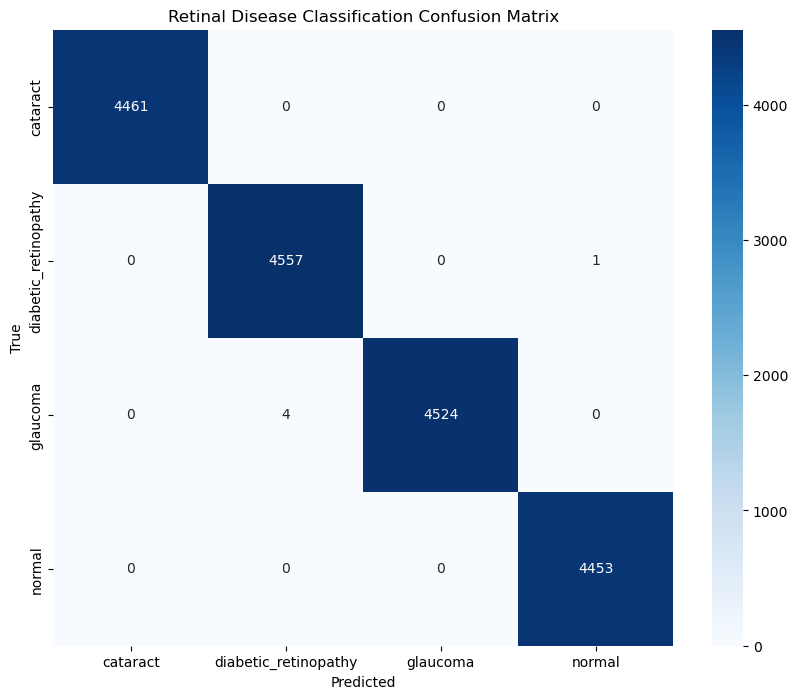

                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00      4461
diabetic_retinopathy       1.00      1.00      1.00      4558
            glaucoma       1.00      1.00      1.00      4528
              normal       1.00      1.00      1.00      4453

            accuracy                           1.00     18000
           macro avg       1.00      1.00      1.00     18000
        weighted avg       1.00      1.00      1.00     18000



In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get true and predicted labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot to indices
y_pred_classes = np.argmax(y_pred, axis=1)  # Model predictions

# 2. Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plot
class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  # Replace with your labels
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Retinal Disease Classification Confusion Matrix")
plt.show()

# 4. Print classification report (optional)
print(classification_report(y_true, y_pred_classes, target_names=class_names))